# 01 - CIGRE European MV benchmark feeder in OpenDSS

This is the first notebook of a step-by-step study on the CIGRE European medium-voltage
distribution benchmark (CIGRE Technical Brochure 575, Section 6.2). The aim here is
modest and deliberate: build the radial base case of the feeder in OpenDSS from a single
data file, solve the power flow, and show that the result agrees with an independent
load-flow tool (pandapower) built from the *same* data, and with the brochure's own
reference table (Table 9.6).

All network parameters come from `data/cigre_mv_european_tb575.json`, the parameter
extraction of the [CIGRE-MV-PSCAD](https://github.com/panas-bhattarai/CIGRE-MV-PSCAD)
repository (copied here unchanged), where every value carries the brochure page it was
read from. The modelling conventions (transformer taps, load model, switch handling)
follow the validation script of that repository so that the two tools are compared like
for like. The builder, solver and result readers live in `cigre_dss.py` next to this
notebook.

Steps:

1. Load the data file and list buses, lines and loads.
2. Draw a one-line diagram.
3. Build the feeder in OpenDSS and solve.
4. Build the pandapower reference and solve.
5. Compare bus voltages: OpenDSS, pandapower, brochure Table 9.6.
6. Plot the voltage profile along both feeders.
7. Compare transformer currents and grid power.
8. Summary.

In [1]:
# Paths: this notebook runs from notebooks/, the modules live in src/ and every
# generated file in results/, so the working directory is moved there once.
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    sys.path.insert(0, os.path.abspath(os.path.join(os.pardir, "src")))
    os.makedirs(os.path.join(os.pardir, "results"), exist_ok=True)
    os.chdir(os.path.join(os.pardir, "results"))

import os, math, json
import numpy as np
import matplotlib.pyplot as plt
import opendssdirect as dss

import cigre_dss as cd            # sits next to this notebook

print("opendssdirect", dss.__version__, "| OpenDSS engine:", dss.Basic.Version()[:40])
print("data file:", os.path.relpath(cd.DATA_PATH))

opendssdirect 0.9.4 | OpenDSS engine: DSS C-API Library version 0.14.5 revisio
data file: ..\data\cigre_mv_european_tb575.json


## 1. The data file

The benchmark is a 20 kV network fed from a 110 kV subtransmission bus (bus 0) through
two 25 MVA transformers. Feeder 1 (buses 1 to 11) is an underground cable network,
feeder 2 (buses 12 to 14) is overhead. Three switches, S1 to S3, are open in the radial
base case: S2 and S3 would close loops inside feeder 1 and S1 would interconnect the
two feeders. The loads at buses 1 and 12 represent other feeders hanging on the same
transformers and dominate the transformer loading.

In [2]:
d = cd.load_data()
hv = d["hv_equivalent"]["network_specific"]
print(d["meta"]["title"])
print(f"System: {d['system']['nominal_voltage_kV']} kV, {d['system']['frequency_Hz']} Hz; "
      f"HV equivalent {hv['short_circuit_power_MVA']} MVA at {hv['nominal_voltage_kV']} kV, R/X = {hv['R_over_X']}  (Table 6.14, p.{hv['page']})")

print("\nTransformers (Table 6.13, p.54; taps Table 9.7, p.104)")
print(f"{'id':4s} {'buses':7s} {'MVA':>5s} {'kV':>8s} {'R ohm':>6s} {'X ohm':>6s} {'tap LV %':>9s}")
for t in d["transformers"]:
    print(f"{t['id']:4s} {t['from_bus']:>2d}-{t['to_bus']:<3d} {t['S_rated_MVA']:5.0f} {t['V1_kV']:>3d}/{t['V2_kV']:<3d} "
          f"{t['Z_ohm_ref_V2']['R']:6.3f} {t['Z_ohm_ref_V2']['X']:6.2f} {t['tap_setting_used_in_power_flow']['secondary_pct']:9.3f}")

print("\nLines (Table 6.12, p.54)")
print(f"{'seg':>3s} {'from':>4s} {'to':>3s} {'km':>5s} {'type':>11s} {'R1':>6s} {'X1':>6s} {'B1 uS':>7s} {'R0':>6s} {'X0':>6s} {'B0 uS':>7s}  switch")
for l in d["lines"]:
    print(f"{l['segment']:3d} {l['from_bus']:4d} {l['to_bus']:3d} {l['length_km']:5.2f} {l['installation']:>11s} "
          f"{l['R1_ohm_per_km']:6.3f} {l['X1_ohm_per_km']:6.3f} {l['B1_uS_per_km']:7.3f} "
          f"{l['R0_ohm_per_km']:6.3f} {l['X0_ohm_per_km']:6.3f} {l['B0_uS_per_km']:7.3f}  {l.get('switch_in_series', '')}")

print("\nLoads (Table 6.15, p.55), constant power")
print(f"{'bus':>3s} {'res kVA':>8s} {'pf':>5s} {'c/i kVA':>8s} {'pf':>5s} {'P kW':>9s} {'Q kvar':>8s}")
Ptot = Qtot = 0.0
for ld in d["loads"]:
    r, c = ld["residential"], ld["commercial_industrial"]
    P = (r["P_kW_derived"] or 0) + (c["P_kW_derived"] or 0)
    Q = (r["Q_kvar_derived"] or 0) + (c["Q_kvar_derived"] or 0)
    Ptot += P; Qtot += Q
    f = lambda x, w: f"{x:{w}}" if x is not None else "-".rjust(w)
    print(f"{ld['bus']:3d} {f(r['S_kVA'], 8)} {f(r['pf'], 5)} {f(c['S_kVA'], 8)} {f(c['pf'], 5)} {P:9.1f} {Q:8.1f}")
print(f"total load: {Ptot/1e3:.3f} MW, {Qtot/1e3:.3f} Mvar")

CIGRE European MV distribution network benchmark - parameter extraction
System: 20 kV, 50 Hz; HV equivalent 5000 MVA at 110 kV, R/X = 0.1  (Table 6.14, p.54)

Transformers (Table 6.13, p.54; taps Table 9.7, p.104)
id   buses     MVA       kV  R ohm  X ohm  tap LV %
TR1   0-1      25 110/20   0.016   1.92     6.250
TR2   0-12     25 110/20   0.016   1.92     3.125

Lines (Table 6.12, p.54)
seg from  to    km        type     R1     X1   B1 uS     R0     X0   B0 uS  switch
  1    1   2  2.82 underground  0.501  0.716  47.493  0.817  1.598  47.493  
  2    2   3  4.42 underground  0.501  0.716  47.493  0.817  1.598  47.493  
  3    3   4  0.61 underground  0.501  0.716  47.493  0.817  1.598  47.493  
  4    4   5  0.56 underground  0.501  0.716  47.493  0.817  1.598  47.493  
  5    5   6  1.54 underground  0.501  0.716  47.493  0.817  1.598  47.493  
  6    6   7  0.24 underground  0.501  0.716  47.493  0.817  1.598  47.493  S2
  7    7   8  1.67 underground  0.501  0.716  47.493  0.817  

## 2. One-line diagram

Bus positions are hand placed; the topology, segment numbers and switch positions are
taken from the data file (Figure 6.5 of the brochure). Dashed segments are the tie lines
with an open switch in the radial base case. The lateral 3-8-9-10-11 runs parallel to
the main branch 3-4-5-6, with bus 7 hanging from bus 8; S2 (6-7) and S3 (11-4) would
close the two loops.

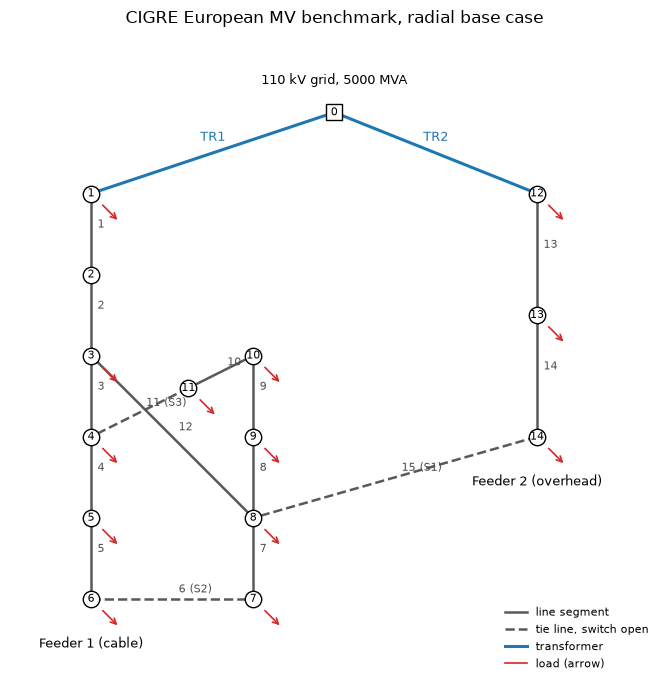

In [3]:
pos = {0: (4.0, 8.0), 1: (1.0, 7.0), 2: (1.0, 6.0), 3: (1.0, 5.0), 4: (1.0, 4.0), 5: (1.0, 3.0),
       6: (1.0, 2.0), 7: (3.0, 2.0), 8: (3.0, 3.0), 9: (3.0, 4.0), 10: (3.0, 5.0), 11: (2.2, 4.6),
       12: (6.5, 7.0), 13: (6.5, 5.5), 14: (6.5, 4.0)}
open_seg = {s["line_segment"] for s in d["switches"]}
tie_switch = {s["line_segment"]: s["id"] for s in d["switches"]}

fig, ax = plt.subplots(figsize=(8, 7))
for l in d["lines"]:
    (x1, y1), (x2, y2) = pos[l["from_bus"]], pos[l["to_bus"]]
    tie = l["segment"] in open_seg
    ax.plot([x1, x2], [y1, y2], color="0.35", lw=1.8, ls="--" if tie else "-", zorder=1)
    lab = f"{l['segment']}" + (f" ({tie_switch[l['segment']]})" if tie else "")
    ax.text((x1 + x2) / 2 + 0.08, (y1 + y2) / 2 + 0.08, lab, fontsize=8, color="0.3")
for t in d["transformers"]:
    (x1, y1), (x2, y2) = pos[t["from_bus"]], pos[t["to_bus"]]
    ax.plot([x1, x2], [y1, y2], color="tab:blue", lw=2.2, zorder=1)
    ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.15, t["id"], fontsize=9, color="tab:blue", ha="center")
loaded = {ld["bus"] for ld in d["loads"] if ld["residential"]["S_kVA"] or ld["commercial_industrial"]["S_kVA"]}
for b, (x, y) in pos.items():
    ax.scatter(x, y, s=140, color="white", edgecolor="black", zorder=3, marker="s" if b == 0 else "o")
    ax.text(x, y, str(b), ha="center", va="center", fontsize=8, zorder=4)
    if b in loaded:
        ax.annotate("", xy=(x + 0.35, y - 0.35), xytext=(x + 0.12, y - 0.12),
                    arrowprops=dict(arrowstyle="->", color="tab:red", lw=1.2))
ax.text(4.0, 8.35, "110 kV grid, 5000 MVA", ha="center", fontsize=9)
ax.text(1.0, 1.4, "Feeder 1 (cable)", fontsize=9, ha="center")
ax.text(6.5, 3.4, "Feeder 2 (overhead)", fontsize=9, ha="center")
ax.plot([], [], color="0.35", lw=1.8, label="line segment")
ax.plot([], [], color="0.35", lw=1.8, ls="--", label="tie line, switch open")
ax.plot([], [], color="tab:blue", lw=2.2, label="transformer")
ax.plot([], [], color="tab:red", lw=1.2, label="load (arrow)")
ax.legend(loc="lower right", fontsize=8, frameon=False)
ax.set_xlim(0, 8); ax.set_ylim(1, 9); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("CIGRE European MV benchmark, radial base case")
plt.tight_layout(); plt.show()

## 3. Build in OpenDSS and solve

`cigre_dss.build_circuit` clears OpenDSS and issues one command per element. The
settings are:

- **Base frequency.** `set defaultbasefrequency=50` is issued *before* `new circuit`.
  Every element takes the default base frequency at creation, and a `Vsource` whose base
  frequency differs from the 50 Hz solution frequency would be treated as a harmonic
  source and produce zero volts.
- **Source.** A `Vsource` at bus 0 with the 5000 MVA, R/X = 0.1 equivalent of Table 6.14.
- **Transformers.** Two `Transformer` elements, delta HV / grounded-wye LV, 0.1 % + j12 %
  on 25 MVA, with the LV taps of Table 9.7 (`tap=1.0625` for TR1, `tap=1.03125` for
  TR2). OpenDSS refers the leakage impedance through the tapped ratio, exactly as
  pandapower does for an LV-side tap. The 20 kV side leads the 110 kV side by 30 degrees
  (`leadlag=lead`), which is the convention of Table 9.6.
- **Lines.** Fifteen `Line` elements with `r1 x1 c1 r0 x0 c0` per km, capacitance from
  $C = B / (2\pi f)$ (uS/km to nF/km). The three tie segments are created with
  `enabled=no`, so they are absent from the solution just as `in_service=False` lines
  are in pandapower.
- **Loads.** One constant-power `Load` (`model=1`) per bus and sector (`b<bus>_res`,
  `b<bus>_com`), with `vminpu=0.5`. OpenDSS switches a load to constant impedance below
  `vminpu`, whose default of 0.95 pu is above the far end of feeder 1 in this case;
  lowering it keeps the loads at constant P and Q at every voltage that occurs in this
  study.

`solve()` then runs a snapshot power flow. The brochure and pandapower hold bus 0 at
exactly 110 kV, 0 degrees as a slack bus, so the source EMF behind the equivalent is
adjusted in a few iterations until bus 0 reads 110.000 kV. The equivalent impedance
stays in the model, where it is available for short-circuit work.

In [4]:
cd.build_circuit(closed_switches=())     # S1, S2, S3 open: radial base case (p.103)
cd.solve()
v_dss = cd.bus_voltages_kv()
trf_dss = cd.transformer_results()
p_dss, q_dss = cd.grid_pq()

dss.Vsources.First()
print(f"converged: {dss.Solution.Converged()} in {dss.Solution.Iterations()} iterations; "
      f"source EMF {dss.Vsources.PU()*110:.3f} kV at {dss.Vsources.AngleDeg():+.3f} deg gives bus 0 = {v_dss[0]['v_kv']:.4f} kV")
print(f"elements: {dss.Circuit.NumCktElements()}, buses: {dss.Circuit.NumBuses()}, "
      f"lines: {len(dss.Lines.AllNames())} defined, {len([1 for l in d['lines'] if l['segment'] not in open_seg])} enabled")
for b, r in v_dss.items():
    print(f"bus {b:2d}: {r['v_kv']:9.4f} kV  {r['ang']:+8.3f} deg")

converged: True in 2 iterations; source EMF 110.467 kV at +0.492 deg gives bus 0 = 110.0000 kV
elements: 36, buses: 15, lines: 15 defined, 12 enabled
bus  0:  110.0000 kV    -0.000 deg
bus  1:   20.4219 kV   +23.022 deg
bus  2:   19.9622 kV   +22.035 deg
bus  3:   19.2433 kV   +20.415 deg
bus  4:   19.2072 kV   +20.318 deg
bus  5:   19.1825 kV   +20.251 deg
bus  6:   19.1533 kV   +20.171 deg
bus  7:   19.1302 kV   +20.173 deg
bus  8:   19.1356 kV   +20.183 deg
bus  9:   19.1165 kV   +20.146 deg
bus 10:   19.0922 kV   +20.084 deg
bus 11:   19.0884 kV   +20.074 deg
bus 12:   19.9934 kV   +24.161 deg
bus 13:   19.8967 kV   +24.110 deg
bus 14:   19.8411 kV   +24.081 deg


## 4. pandapower reference

`cigre_dss.pandapower_reference` is the load flow of the CIGRE-MV-PSCAD validation
script, reproduced here unchanged in substance: same data, external grid at bus 0 with
`vm_pu = 1`, transformers from parameters with `tap_side="lv"` and `shift_degree = -30`,
lines from sequence parameters, tie lines out of service, constant-power loads.

In [5]:
v_pp, trf_pp, p_pp, q_pp = cd.pandapower_reference(d, closed_switches=())
for b, r in v_pp.items():
    print(f"bus {b:2d}: {r['v_kv']:9.4f} kV  {r['ang']:+8.3f} deg")

bus  0:  110.0000 kV    +0.000 deg

bus  1:   20.4219 kV   +23.022 deg

bus  2:   19.9622 kV   +22.035 deg

bus  3:   19.2433 kV   +20.415 deg

bus  4:   19.2072 kV   +20.318 deg

...

bus 10:   19.0922 kV   +20.084 deg

bus 11:   19.0884 kV   +20.074 deg

bus 12:   19.9934 kV   +24.161 deg

bus 13:   19.8967 kV   +24.110 deg

bus 14:   19.8411 kV   +24.081 deg

## 5. Bus voltages: OpenDSS, pandapower, brochure

Line-to-line voltage magnitude per bus and the percentage error of OpenDSS against
each reference. The brochure column is Table 9.6 (phase pair AB; the three pairs are
identical). Angles are relative to bus 0.

In [6]:
tb = {x["bus"]: x for x in d["powerflow_reference"]["buses"]}
rows = []
print(f"{'bus':>3s} {'OpenDSS kV':>11s} {'pandapower kV':>14s} {'TB575 kV':>9s} | {'dss-pp %':>9s} {'dss-TB %':>9s} | {'ang dss':>8s} {'ang pp':>7s} {'ang TB':>7s}")
for b in range(15):
    o, p, t = v_dss[b]["v_kv"], v_pp[b]["v_kv"], tb[b]["V_LL_rms_kV"]["AB"]
    e_pp, e_tb = (o / p - 1) * 100, (o / t - 1) * 100
    rows.append((b, o, p, t, e_pp, e_tb))
    print(f"{b:3d} {o:11.4f} {p:14.4f} {t:9.2f} | {e_pp:+9.5f} {e_tb:+9.3f} | {v_dss[b]['ang']:8.3f} {v_pp[b]['ang']:7.3f} {tb[b]['angle_deg']['AB']:7.2f}")
worst_pp = max(abs(r[4]) for r in rows); worst_tb = max(abs(r[5]) for r in rows)
worst_ang = max(abs(v_dss[b]["ang"] - v_pp[b]["ang"]) for b in range(15))
print(f"\nworst |OpenDSS - pandapower| = {worst_pp:.5f} %  (angle {worst_ang:.4f} deg)")
print(f"worst |OpenDSS - brochure|   = {worst_tb:.3f} %  at bus {max(rows, key=lambda r: abs(r[5]))[0]}")
assert worst_pp < 0.05, "OpenDSS and pandapower differ by more than 0.05 %" 

bus  OpenDSS kV  pandapower kV  TB575 kV |  dss-pp %  dss-TB % |  ang dss  ang pp  ang TB

  0    110.0000       110.0000    110.00 |  -0.00000    -0.000 |   -0.000   0.000    0.00

  1     20.4219        20.4219     20.52 |  -0.00001    -0.478 |   23.022  23.022   23.66

  2     19.9622        19.9622     20.09 |  -0.00001    -0.636 |   22.035  22.035   22.75

  3     19.2433        19.2433     19.43 |  -0.00001    -0.961 |   20.415  20.415   21.25

...

 12     19.9934        19.9934     20.04 |  -0.00001    -0.233 |   24.161  24.161   24.50

 13     19.8967        19.8967     19.94 |  -0.00001    -0.217 |   24.110  24.110   24.45

 14     19.8411        19.8411     19.88 |  -0.00001    -0.196 |   24.081  24.081   24.43


worst |OpenDSS - pandapower| = 0.00001 %  (angle 0.0000 deg)

worst |OpenDSS - brochure|   = 1.045 %  at bus 11

## 6. Voltage profile

Voltage in per unit of 20 kV along feeder 1, in the order of the radial path from the
transformer (1-2-3-4-5-6 on the main branch, then 3-8-9-10-11 on the lateral, with 7 hanging
from 8), and along feeder 2 (12-13-14). Bus order on the x-axis is the bus number; the
lines connecting the points are a visual aid only.

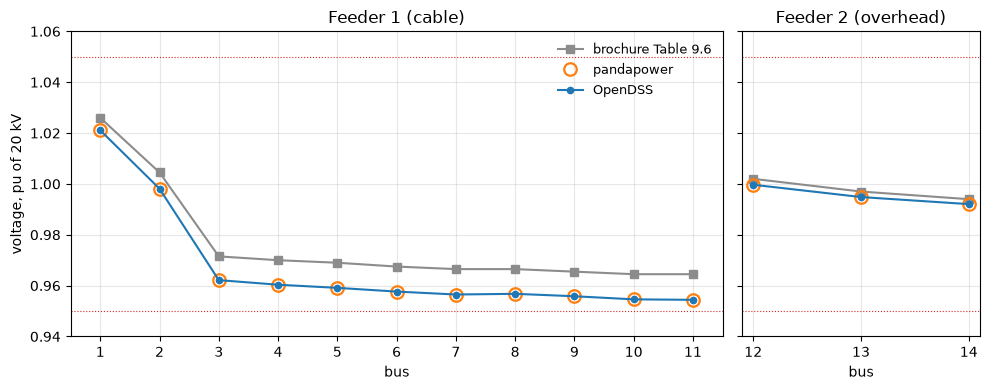

In [7]:
f1 = list(range(1, 12)); f2 = [12, 13, 14]
def pu(src, buses):
    return [src[b] / 20.0 for b in buses]
kv_dss = {b: v_dss[b]["v_kv"] for b in range(15)}
kv_pp = {b: v_pp[b]["v_kv"] for b in range(15)}
kv_tb = {b: tb[b]["V_LL_rms_kV"]["AB"] for b in range(15)}

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True, gridspec_kw=dict(width_ratios=[11, 4]))
for ax, buses, title in zip(axes, (f1, f2), ("Feeder 1 (cable)", "Feeder 2 (overhead)")):
    ax.plot(buses, pu(kv_tb, buses), "s-", color="0.55", ms=6, label="brochure Table 9.6")
    ax.plot(buses, pu(kv_pp, buses), "o", color="tab:orange", ms=9, mfc="none", mew=1.6, label="pandapower")
    ax.plot(buses, pu(kv_dss, buses), ".-", color="tab:blue", ms=9, label="OpenDSS")
    for y in (0.95, 1.05):
        ax.axhline(y, color="tab:red", lw=0.8, ls=":")
    ax.set_xticks(buses); ax.set_xlabel("bus"); ax.set_title(title); ax.grid(alpha=0.3)
axes[0].set_ylabel("voltage, pu of 20 kV"); axes[0].set_ylim(0.94, 1.06)
axes[0].legend(loc="upper right", fontsize=9, frameon=False)
plt.tight_layout(); plt.show()

## 7. Transformer currents and grid power

Secondary (20 kV side) current of each transformer and the active and reactive power
drawn from the 110 kV bus. The brochure only tabulates currents (Table 9.6); the P/Q
comparison is between the two tools.

In [8]:
br = {str(x["to_bus"]): x for x in d["powerflow_reference"]["branches"] if str(x["from_bus"]) == "0"}
print(f"{'':5s} {'OpenDSS A':>10s} {'pandapower A':>13s} {'TB575 A':>8s} | {'dss-pp %':>9s} {'dss-TB %':>9s}")
for t in d["transformers"]:
    o, p, r = trf_dss[t["id"]]["i_lv_a"], trf_pp[t["id"]]["i_lv_a"], br[str(t["to_bus"])]["I_rms_A"]["A"]
    print(f"{t['id']:5s} {o:10.2f} {p:13.2f} {r:8.2f} | {(o/p-1)*100:+9.5f} {(o/r-1)*100:+9.3f}")
print(f"\n{'':5s} {'OpenDSS':>18s} {'pandapower':>18s}")
for t in d["transformers"]:
    a, b_ = trf_dss[t["id"]], trf_pp[t["id"]]
    print(f"{t['id']:5s} {a['p_hv_mw']:8.3f} MW {a['q_hv_mvar']:6.3f} Mvar {b_['p_hv_mw']:8.3f} MW {b_['q_hv_mvar']:6.3f} Mvar")
print(f"grid  {p_dss:8.3f} MW {q_dss:6.3f} Mvar {p_pp:8.3f} MW {q_pp:6.3f} Mvar")
print(f"\ngrid P difference {abs(p_dss-p_pp)*1e3:.3f} kW, Q difference {abs(q_dss-q_pp)*1e3:.3f} kvar")

       OpenDSS A  pandapower A  TB575 A |  dss-pp %  dss-TB %

TR1       710.42        710.42   727.89 |  +0.00001    -2.400

TR2       611.56        611.56   612.21 |  +0.00001    -0.105


                 OpenDSS         pandapower

TR1     24.400 MW  9.398 Mvar   24.400 MW  9.398 Mvar

TR2     20.607 MW  7.256 Mvar   20.607 MW  7.256 Mvar

grid    45.008 MW 16.654 Mvar   45.008 MW 16.654 Mvar


grid P difference 0.000 kW, Q difference 0.045 kvar

## 8. Summary

- The OpenDSS model of the radial base case reproduces the pandapower load flow of the
  same data file to solver tolerance: the worst bus-voltage difference is about
  1e-5 % (table in step 5) and the transformer currents and grid P/Q agree to the same
  level. The two tools therefore implement the same network with the same conventions.
- Against the brochure's Table 9.6 the OpenDSS voltages are about 0.5 % low at the
  transformer secondaries and about 1 % low at the end of feeder 1, with the offset
  growing along the feeder. This is a convention effect, documented in the
  CIGRE-MV-PSCAD repository: the brochure's own calculation keeps the 12 % transformer
  impedance on the untapped base and treats the loads as constant impedance, whereas
  pandapower and OpenDSS refer the impedance through the tapped ratio and hold P and Q
  constant. With the brochure's two conventions adopted, Table 9.6 is reproduced to
  0.03 %; the offset belongs to the method, not the data, and is expected rather than
  corrected. About 1 % is therefore the tolerance to expect against the table. The TR1
  secondary current (710 A against 728 A in the table, -2.4 %) has the same origin: the
  brochure's constant-impedance load at bus 1 draws proportionally more current at its
  0.5 % higher bus voltage.
- The source EMF behind the 5000 MVA equivalent comes out at 110.47 kV so that bus 0
  sits at exactly 110 kV, 0 degrees, the slack condition of the brochure and of
  pandapower.

The next notebook adds photovoltaic generation to feeder 1 and asks where and when the
voltage leaves the 0.95 to 1.05 pu band.

Files: `cigre_dss.py` (builder, solver, result readers, pandapower reference),
`data/cigre_mv_european_tb575.json` and this notebook.